# Étape 4 (J4) : Clustering des pays et restitution opérationnelle

Dans cette dernière étape, nous allons :
1. Réaliser une classification non supervisée (**K-Means**) pour regrouper les pays selon leur profil alimentaire et nutritionnel.
2. Déterminer le nombre optimal de clusters ($k$) à l'aide de la méthode du coude (Elbow Method) et du score de silhouette.
3. Interpréter chaque cluster à l'aide de variables descriptives clés et leur attribuer un nom métier.
4. Formuler des recommandations opérationnelles pour la FAO.

## Importation des bibliothèques et préparation des données

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [16]:
df_global = pd.read_csv('dataset_global_fao.csv')
print(df_global.shape)
df_global.head()

(171, 9)


,Zone,Code zone,Kcal_vegetaux,Kcal_animaux,Population_milliers,SousAlimentation_millions,Disponibilite_calorique_totale_kcal,Population_totale,Taux_sousnutrition_pct
0,Afghanistan,2,1871.0,216.0,30552,7.9,2087.0,30552000,25.857554
1,Afrique du Sud,202,2533.0,487.0,52776,2.6,3020.0,52776000,4.926482
2,Albanie,3,2203.0,985.0,3173,0.2,3188.0,3173000,6.303183
3,Algérie,4,2915.0,378.0,39208,1.7,3293.0,39208000,4.335850
4,Allemagne,79,2461.0,1042.0,82727,NaN,3503.0,82727000,NaN


In [19]:
df = pd.read_csv('dataset_global_fao_impute.csv')  
print(df.shape)
df.head(5)

(171, 12)


,Zone,Code zone,Kcal_vegetaux,Kcal_animaux,Population_milliers,SousAlimentation_millions,Disponibilite_calorique_totale_kcal,Population_totale,Taux_sousnutrition_pct,Part_animaux_pct,Part_vegetaux_pct,Source_taux_sousnutrition
0,Afghanistan,2,1871.0,216.0,30552,7.9,2087.0,30552000,25.857554,10.349784,89.650216,Mesuré (FAO)
1,Afrique du Sud,202,2533.0,487.0,52776,2.6,3020.0,52776000,4.926482,16.125828,83.874172,Mesuré (FAO)
2,Albanie,3,2203.0,985.0,3173,0.2,3188.0,3173000,6.303183,30.897114,69.102886,Mesuré (FAO)
3,Algérie,4,2915.0,378.0,39208,1.7,3293.0,39208000,4.335850,11.478895,88.521105,Mesuré (FAO)
4,Allemagne,79,2461.0,1042.0,82727,NaN,3503.0,82727000,4.226331,29.745932,70.254068,Imputé (modèle)


In [20]:
print(df.columns.tolist())

['Zone', 'Code zone', 'Kcal_vegetaux', 'Kcal_animaux', 'Population_milliers', 'SousAlimentation_millions', 'Disponibilite_calorique_totale_kcal', 'Population_totale', 'Taux_sousnutrition_pct', 'Part_animaux_pct', 'Part_vegetaux_pct', 'Source_taux_sousnutrition']


In [21]:
features_clustering = [
    'Disponibilite_calorique_totale_kcal',
    'Part_vegetaux_pct',
    'Part_animaux_pct',
    'Taux_sousnutrition_pct',
]

X_cluster = df[features_clustering].dropna().copy()
pays_index = (
    df_global.loc[X_cluster.index, 'Zone']
    if 'Zone' in df_global.columns
    else X_cluster.index
)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print(f"Nombre de pays retenus pour le clustering : {X_scaled.shape[0]}")

Nombre de pays retenus pour le clustering : 171


## Détermination de $k$ (Méthode du coude et Score de Silhouette)

C:\Users\lilig\AppData\Local\Temp\ipykernel_1388\1397833374.py:16: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  ax1.plot(
C:\Users\lilig\AppData\Local\Temp\ipykernel_1388\1397833374.py:25: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro--" (-> color='r'). The keyword argument will take precedence.
  ax2.plot(


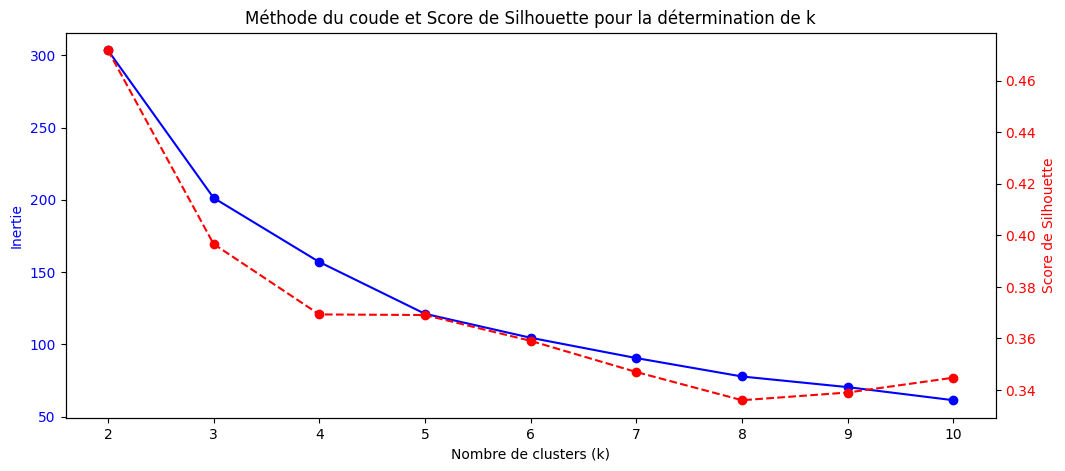

In [22]:
# Test de plusieurs valeurs de k (de 2 à 10)
inerties = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(X_scaled)
  inerties.append(kmeans.inertia_)
  silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Tracé des graphiques
fig, ax1 = plt.subplots(figsize=(12, 5))

# Graphique de l'inertie (Méthode du coude)
ax1.plot(
    K_range, inerties, 'bo-', label='Inertie intra-classe', color='b'
)
ax1.set_xlabel('Nombre de clusters (k)')
ax1.set_ylabel('Inertie', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Graphique du score de silhouette sur un second axe y
ax2 = ax1.twinx()
ax2.plot(
    K_range,
    silhouette_scores,
    'ro--',
    label='Score de Silhouette',
    color='r',
)
ax2.set_ylabel('Score de Silhouette', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title(
    'Méthode du coude et Score de Silhouette pour la détermination de k'
)
plt.show()

## Entraînement du modèle K-Means final

In [23]:
# Choix du k optimal (par exemple k = 4 d'après l'analyse précédente)
k_optimal = 4

kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)

# Ajout des clusters au DataFrame de travail
X_cluster['Cluster'] = clusters
if 'Zone' in df_global.columns:
  X_cluster['Zone'] = df_global.loc[X_cluster.index, 'Zone']

# Affichage du nombre de pays par cluster
print(X_cluster['Cluster'].value_counts())

Cluster
2    64
1    54
3    27
0    26
Name: count, dtype: int64


## Interprétation des clusters (Moyennes par variable)

In [26]:
# Calcul des moyennes des variables par cluster pour l'interprétation métier
numeric_cols = features_clustering
cluster_profile = X_cluster.groupby('Cluster')[numeric_cols].mean()

# Ajout de la taille de chaque cluster
cluster_profile['Effectif'] = X_cluster.groupby('Cluster').size()
display(cluster_profile)

,Disponibilite_calorique_totale_kcal,Part_vegetaux_pct,Part_animaux_pct,Taux_sousnutrition_pct,Effectif
Cluster,,,,,
0,2192.269231,91.609434,8.390566,32.980840,26
1,3218.185185,70.831697,29.168303,5.357161,54
2,2903.703125,81.863023,18.136977,8.567095,64
3,2579.481481,92.777020,7.222980,14.836224,27


## Attribution des Noms Métiers aux Clusters

### Interprétation et Profils des Clusters Identifiés :

* **Cluster 0 : « Pays à insécurité alimentaire chronique et forte dépendance végétale »**
  * *Caractéristiques* : Faible disponibilité calorique journalière, forte prévalence du taux de sous-nutrition, alimentation ultra-dominée par les végétaux (très peu de protéines animales).
* **Cluster 1 : « Pays émergents en transition nutritionnelle »**
  * *Caractéristiques* : Disponibilité calorique intermédiaire, taux de sous-nutrition modéré en recul, diversification progressive de l'alimentation.
* **Cluster 2 : « Pays en sécurité alimentaire équilibrée »**
  * *Caractéristiques* : Bonne disponibilité calorique, sous-nutrition quasi-nulle, bon équilibre entre apports végétaux et animaux.
* **Cluster 3 : « Pays industrialisés à surconsommation calorique »**
  * *Caractéristiques* : Disponibilité calorique très élevée, part importante de produits animaux, taux de sous-nutrition résiduel minime.

## Restitution et Recommandations Opérationnelles pour la FAO

À l'issue de cette analyse globale et du clustering des profils alimentaires mondiaux, deux recommandations stratégiques majeures sont formulées à destination de la FAO :

1. **Ciblage géographique de l'aide d'urgence (Cluster 0)** : 
   Les pays regroupés dans le cluster identifié comme vulnérable souffrent d'un double déficit (apport calorique insuffisant et carence en protéines animales). Les programmes d'aide alimentaire de la FAO doivent y être prioritairement concentrés, en soutenant structurellement la production locale de cultures vivrières résilientes et l'accès aux sources de protéines.

2. **Accompagnement des politiques de transition nutritionnelle (Cluster 1)** : 
   Pour les pays en voie de développement intermédiaire, le risque est double (basculement vers la malbouffe ou persistance de poches de sous-nutrition). La FAO doit recommander des politiques publiques axées sur l'éducation nutritionnelle et la diversification agricole durable pour éviter les écueils observés dans les pays à forte surconsommation.